# Proyecto de pruebas A/B

## 1. Objetivos del estudio

**Objetivo principal:** comprobar si la introducción de un sistema de recomendaciones mejorado (grupo B) incrementa la conversión del embudo respecto al control (grupo A) durante los **14 días posteriores al registro**.

**Eventos del embudo:**
- `product_page`: visita a página de producto
- `product_cart`: agregar al carrito
- `purchase`: compra

**Hipótesis por etapa (prueba de proporciones):**
- **H0:** La proporción de usuarios que alcanzan la etapa es igual en A y B.
- **H1:** La proporción de usuarios que alcanzan la etapa difiere entre A y B.


## 2. Carga de datos y configuración

- `ab_project_marketing_events_us.csv`: calendario de campañas de marketing
- `final_ab_new_users_upd_us.csv`: usuarios nuevos
- `final_ab_events_upd_us.csv`: eventos de actividad de esos usuarios
- `final_ab_participants_upd_us.csv`: participación en pruebas y grupos

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import statsmodels.stats.proportion as smprop
from statsmodels.stats.proportion import proportions_ztest
from scipy import stats
from scipy.stats import chi2_contingency
from scipy.stats import norm
import math

np.random.seed(42)

import matplotlib
import statsmodels
print('Versiones:')
print('pandas:', pd.__version__)
print('numpy:', np.__version__)
print('matplotlib:', matplotlib.__version__)
print('statsmodels:', statsmodels.__version__)


Versiones:
pandas: 2.3.3
numpy: 2.4.0
matplotlib: 3.10.8
statsmodels: 0.14.6


In [28]:
marketing = pd.read_csv('ab_project_marketing_events_us.csv')
users = pd.read_csv('final_ab_new_users_upd_us.csv')
events = pd.read_csv('final_ab_events_upd_us.csv')
parts = pd.read_csv('final_ab_participants_upd_us.csv')

print(marketing.info())
print(users.info())
print(events.info())
print(parts.info())

print(marketing.head())
print(users.head())
print(events.head())
print(parts.head())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   name       14 non-null     object
 1   regions    14 non-null     object
 2   start_dt   14 non-null     object
 3   finish_dt  14 non-null     object
dtypes: object(4)
memory usage: 580.0+ bytes
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58703 entries, 0 to 58702
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     58703 non-null  object
 1   first_date  58703 non-null  object
 2   region      58703 non-null  object
 3   device      58703 non-null  object
dtypes: object(4)
memory usage: 1.8+ MB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 423761 entries, 0 to 423760
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   user_id     423761 non

## 3. Exploración inicial de datos (tipos, nulos, duplicados)

- Convertir columnas de fecha a datetime.
- Revisar valores ausentes y duplicados.
- Confirmar rangos temporales.

In [29]:
# Conversión de tipos
marketing['start_dt'] = pd.to_datetime(marketing['start_dt'])
marketing['finish_dt'] = pd.to_datetime(marketing['finish_dt'])

users['first_date'] = pd.to_datetime(users['first_date'])
events['event_dt'] = pd.to_datetime(events['event_dt'])

# Resumen de calidad
for name, df in [('marketing', marketing), ('users', users), ('events', events), ('parts', parts)]:
    print(f'\n{name.upper()}')
    print('shape:', df.shape)
    print('duplicados:', df.duplicated().sum())
    print('nulos (%):')
    print((df.isna().mean()*100).round(2).sort_values(ascending=False).head(10))

print('\nRango de fechas:')
print('users first_date:', users['first_date'].min(), '-', users['first_date'].max())
print('events event_dt:', events['event_dt'].min(), '-', events['event_dt'].max())
print((users['first_date'].min()) - (users['first_date'].max()))
print((events['event_dt'].min()) - (events['event_dt'].max()))


MARKETING
shape: (14, 4)
duplicados: 0
nulos (%):
name         0.0
regions      0.0
start_dt     0.0
finish_dt    0.0
dtype: float64

USERS
shape: (58703, 4)
duplicados: 0
nulos (%):
user_id       0.0
first_date    0.0
region        0.0
device        0.0
dtype: float64

EVENTS
shape: (423761, 4)
duplicados: 0
nulos (%):
details       85.77
user_id        0.00
event_dt       0.00
event_name     0.00
dtype: float64

PARTS
shape: (14525, 3)
duplicados: 0
nulos (%):
user_id    0.0
group      0.0
ab_test    0.0
dtype: float64

Rango de fechas:
users first_date: 2020-12-07 00:00:00 - 2020-12-23 00:00:00
events event_dt: 2020-12-07 00:00:33 - 2020-12-30 23:36:33
-16 days +00:00:00
-24 days +00:24:00


Durante la exploración inicial de los datos se convirtió a formato datetime todas las columnas de fecha relevantes (start_dt, finish_dt, first_date, event_dt) para permitir análisis temporales correctos y el cálculo de la ventana de 14 días; la revisión de valores ausentes mostró que únicamente la columna details del dataset de eventos contiene un alto porcentaje de nulos, lo cual es esperado ya que solo se completa para eventos de compra, por lo que no fue necesario eliminar ni imputar registros; adicionalmente, se verificó que ninguno de los cuatro datasets presenta filas duplicadas, por lo que no se requirió depuración adicional, concluyéndose que los datos tienen una calidad estructural adecuada y son plenamente aptos para el análisis estadístico sin aplicar procesos de limpieza agresivos.

In [30]:
# --- REVIEWER FIX: usar última fecha real del dataset (evita inconsistencias) ---
last_event_date = events['event_dt'].max().normalize()
required_days = 14

# Usuarios necesitan tener al menos 14 días observables desde su registro
cutoff_date = last_event_date - pd.Timedelta(days=required_days-1)
print(f'Última fecha de eventos en datos: {last_event_date}')
print(f'Fecha de corte para registros (ventana completa 14d): {cutoff_date}')


Última fecha de eventos en datos: 2020-12-30 00:00:00
Fecha de corte para registros (ventana completa 14d): 2020-12-17 00:00:00


In [ ]:
# Filtrar usuarios (por fecha de registro) para asegurar ventana completa de 14 días
users_filtered = users[users['first_date'] <= cutoff_date]

# Mantener todos los eventos disponibles hasta el último día observado en el dataset
events_filtered = events[events['event_dt'] <= last_event_date]

# Filtrar participantes (por usuarios válidos y experimento)
parts_filtered = parts[
    (parts['user_id'].isin(users_filtered['user_id'])) & 
    (parts['ab_test'] == 'recommender_system_test')
]


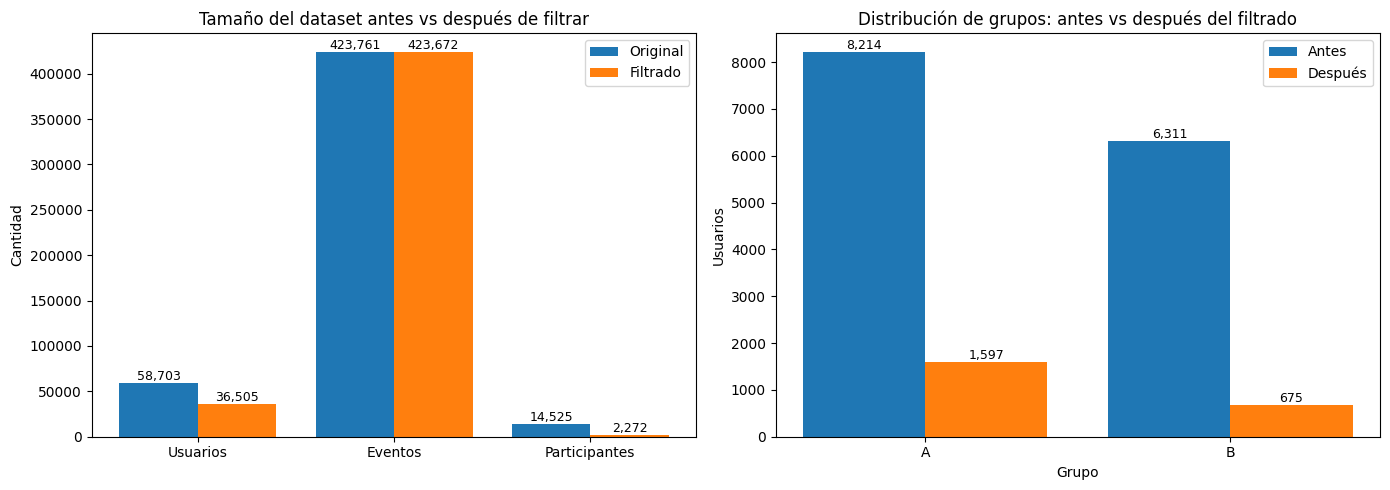

=== DISTRIBUCIÓN ORIGINAL (ANTES DEL FILTRO) ===
group
A    8214
B    6311
Name: count, dtype: int64

Proporción original por grupo:
Grupo A: 8,214 usuarios (56.6%)
Grupo B: 6,311 usuarios (43.4%)

=== DISTRIBUCIÓN DESPUÉS DEL FILTRO ===
group
A    1597
B     675
Name: count, dtype: int64

Proporción filtrada por grupo:
Grupo A: 1,597 usuarios (70.3%)
Grupo B: 675 usuarios (29.7%)



In [32]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Función para añadir etiquetas
def add_labels(ax, bars):
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, height, f'{int(height):,}',
                ha='center', va='bottom', fontsize=9)

# --- Gráfica 1: Tamaño del dataset antes vs después ---
labels = ['Usuarios', 'Eventos', 'Participantes']
original = [len(users), len(events), len(parts)]
filtered = [len(users_filtered), len(events_filtered), len(parts_filtered)]
x = np.arange(len(labels))

bars1 = axes[0].bar(x - 0.2, original, width=0.4, label='Original')
bars2 = axes[0].bar(x + 0.2, filtered, width=0.4, label='Filtrado')

axes[0].set_xticks(x)
axes[0].set_xticklabels(labels)
axes[0].set_title('Tamaño del dataset antes vs después de filtrar')
axes[0].set_ylabel('Cantidad')
axes[0].legend()

add_labels(axes[0], bars1)
add_labels(axes[0], bars2)

# --- Gráfica 2: Distribución de grupos antes vs después ---
groups = sorted(parts['group'].unique())
before = [parts[parts['group']==g].shape[0] for g in groups]
after = [parts_filtered[parts_filtered['group']==g].shape[0] for g in groups]

x2 = np.arange(len(groups))

bars3 = axes[1].bar(x2 - 0.2, before, width=0.4, label='Antes')
bars4 = axes[1].bar(x2 + 0.2, after, width=0.4, label='Después')

axes[1].set_xticks(x2)
axes[1].set_xticklabels(groups)
axes[1].set_title('Distribución de grupos: antes vs después del filtrado')
axes[1].set_xlabel('Grupo')
axes[1].set_ylabel('Usuarios')
axes[1].legend()

add_labels(axes[1], bars3)
add_labels(axes[1], bars4)

plt.tight_layout()
plt.show()

# === COMPARACIÓN DE PROPORCIONES ANTES/DESPUÉS DEL FILTRO ===

print("=== DISTRIBUCIÓN ORIGINAL (ANTES DEL FILTRO) ===")
original_distribution = parts['group'].value_counts()
print(original_distribution)
print()

print("Proporción original por grupo:")
for group, count in original_distribution.items():
    percentage = (count / len(parts)) * 100
    print(f'Grupo {group}: {count:,} usuarios ({percentage:.1f}%)')

print("\n" + "="*50)

print("=== DISTRIBUCIÓN DESPUÉS DEL FILTRO ===")
filtered_distribution = parts_filtered['group'].value_counts()
print(filtered_distribution)
print()

print("Proporción filtrada por grupo:")
for group, count in filtered_distribution.items():
    percentage = (count / len(parts_filtered)) * 100
    print(f'Grupo {group}: {count:,} usuarios ({percentage:.1f}%)')

print("\n" + "="*50)

Antes del filtrado, la muestra presentaba un desbalance moderado entre los grupos, con 56.6% de usuarios en el grupo A y 43.4% en el grupo B. Sin embargo, tras aplicar los criterios de depuración (selección de participantes válidos, control de ventana de observación y exclusión de usuarios fuera del experimento), el desbalance aumenta de forma considerable, pasando a 70.3% para el grupo A y 29.7% para el grupo B. Este cambio indica que el proceso de filtrado sí alteró la composición relativa de los grupos, lo que constituye una limitación importante del experimento, ya que reduce el poder estadístico y puede afectar la estabilidad de la comparación entre tratamientos.

## 4. Análisis Exploratorio de Datos (EDA)
- Conversión a lo largo del embudo
- Distribución de actividad por usuario
- Consistencia de asignación de grupos
- Comportamiento temporal de los eventos
- Factores críticos previos al análisis A/B

In [42]:
# Verificar eventos disponibles en datos filtrados
print("=== EVENTOS DISPONIBLES ===")
event_counts = events_filtered['event_name'].value_counts()
print(event_counts)
print()

# Verificar los eventos del embudo
embudo_events = ['product_page', 'product_cart', 'purchase']
print("=== VERIFICACIÓN DE EVENTOS DEL EMBUDO ===")
for event in embudo_events:
    if event in event_counts.index:
        print(f'{event}: {event_counts[event]:,} eventos')
    else:
        print(f'{event}: NO ENCONTRADO')

=== EVENTOS DISPONIBLES ===
event_name
login           182429
product_page    120840
purchase         60299
product_cart     60104
Name: count, dtype: int64

=== VERIFICACIÓN DE EVENTOS DEL EMBUDO ===
product_page: 120,840 eventos
product_cart: 60,104 eventos
purchase: 60,299 eventos


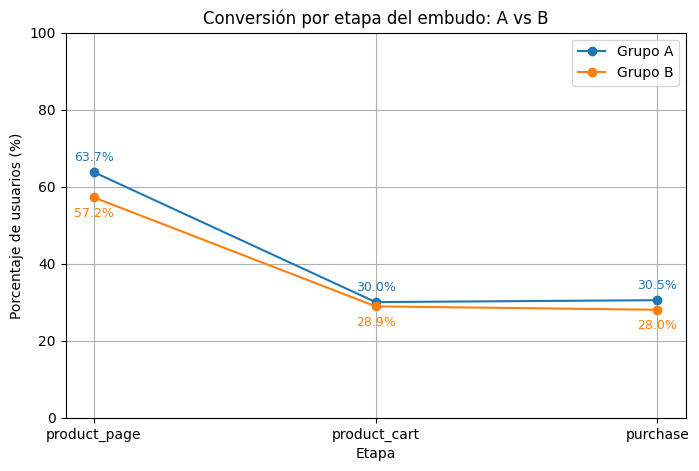

In [43]:
# --- 1) Añadir columna group ---
events_with_group = events_filtered.merge(
    parts_filtered[['user_id', 'group']],
    on='user_id',
    how='inner'
)

# --- 2) Filtrar eventos del embudo ---
events_funnel = events_with_group[events_with_group['event_name'].isin(embudo_events)].copy()

funnel_order = ['product_page', 'product_cart', 'purchase']

# --- 3) Calcular conversión por grupo ---
conversion = {}

for g in ['A', 'B']:
    group_data = events_funnel[events_funnel['group'] == g]
    
    users_by_event = group_data.groupby('event_name')['user_id'].nunique()
    total_users = parts_filtered[parts_filtered['group'] == g]['user_id'].nunique()
    
    conversion[g] = (users_by_event / total_users).reindex(funnel_order)

# --- 4) Gráfica comparativa ---
plt.figure(figsize=(8, 5))

lines = {} 

for g in ['A', 'B']:
    rates = conversion[g] * 100
    line, = plt.plot(rates.index, rates.values, marker='o', label=f'Grupo {g}')
    lines[g] = line  # guardar referencia

plt.title('Conversión por etapa del embudo: A vs B')
plt.xlabel('Etapa')
plt.ylabel('Porcentaje de usuarios (%)')
plt.ylim(0, 100)
plt.grid(True)
plt.legend()

offsets = {'A': 3.0, 'B': -5.0}

for g in ['A', 'B']:
    vals = (conversion[g] * 100).values
    color = lines[g].get_color()  
    for i, v in enumerate(vals):
        if pd.notna(v):
            plt.text(i, v + offsets[g], f'{v:.1f}%',
                     ha='center', fontsize=9, color=color)

plt.show()


La gráfica muestra que el grupo B presenta consistentemente menores tasas de conversión que el grupo A en las tres etapas del embudo. La diferencia es más marcada en la etapa inicial product_page, donde el grupo A alcanza aproximadamente 63.7% de conversión frente a 57.2% en el grupo B, lo que sugiere que el nuevo sistema de recomendaciones no mejora la interacción inicial del usuario con el catálogo y, por el contrario, la debilita. En las etapas posteriores (product_cart y purchase) las brechas entre grupos se reducen, pero el grupo B no logra superar al grupo de control en ningún punto del proceso. En conjunto, el patrón observado contradice el objetivo del experimento de lograr un incremento mínimo del 10% en cada etapa del embudo y refuerza la conclusión de que el cambio propuesto no aporta valor al flujo de compra actual.

In [44]:
# Analisis de la distribución de eventos por usuario en ambos grupos
events_per_user = events_with_group.groupby(['group','user_id']).size()

# Estadísticas descriptivas por grupo
stats_by_group = events_per_user.groupby('group').describe()

print("Distribución de eventos por usuario:")
print(stats_by_group)

Distribución de eventos por usuario:
        count      mean       std  min  25%  50%  75%   max
group                                                      
A      1597.0  6.994991  3.815609  1.0  4.0  6.0  9.0  24.0
B       675.0  6.088889  3.629476  1.0  3.0  6.0  8.0  28.0


### ¿El número de eventos por usuario está distribuido equitativamente? 

La tabla muestra que, tras el filtrado, el nivel de actividad por usuario es comparable entre los grupos, aunque el grupo A presenta una actividad ligeramente mayor en promedio (media de 7.0 eventos frente a 6.1 en el grupo B). Las medianas son iguales en ambos grupos (6 eventos), lo que indica que el comportamiento típico de los usuarios es muy similar. Sin embargo, el grupo A presenta cuartiles superiores más altos (75% = 9 frente a 8 en B), lo que sugiere una mayor concentración de usuarios moderadamente activos. Aunque el grupo B alcanza un máximo ligeramente superior (28 vs 24), este efecto se explica por unos pocos usuarios extremos y no altera el patrón general. En conjunto, no se observa un sesgo fuerte de actividad que justifique por sí mismo las diferencias de conversión observadas en el embudo.


In [45]:
# ¿Hay usuarios que están presentes en ambas muestras?

A_users = set(events_with_group.loc[events_with_group['group'] == 'A', 'user_id'])
B_users = set(events_with_group.loc[events_with_group['group'] == 'B', 'user_id'])

in_both = A_users.intersection(B_users)

print(f'Usuarios presentes en ambos grupos: {len(in_both)}')

Usuarios presentes en ambos grupos: 0


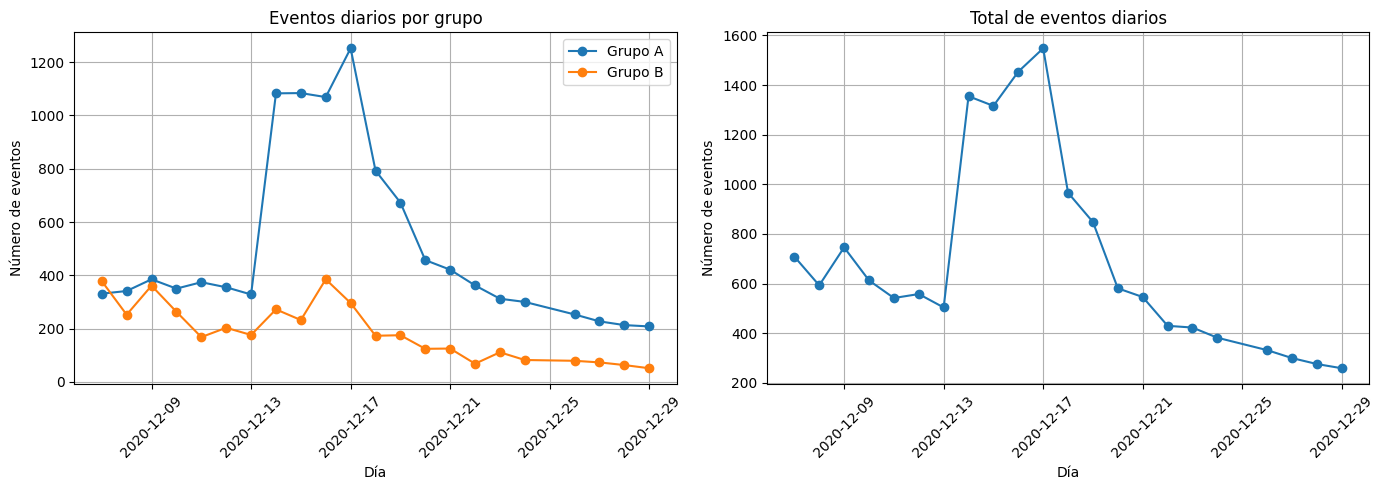

In [46]:
# Distribución del número de eventos entre los días

# Asegurar columna de día
events_with_group['event_day'] = events_with_group['event_dt'].dt.date

# --- Agregación ---
daily = (events_with_group
         .groupby(['event_day', 'group'])
         .size()
         .reset_index(name='events_cnt'))

daily_pivot = daily.pivot(index='event_day', columns='group', values='events_cnt').fillna(0)

daily_total = (events_with_group
               .groupby('event_day')
               .size()
               .reset_index(name='events_cnt'))

# --- Figura combinada ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 🔹 Izquierda: A vs B
for g in daily_pivot.columns:
    axes[0].plot(daily_pivot.index, daily_pivot[g], marker='o', label=f'Grupo {g}')

axes[0].set_title('Eventos diarios por grupo')
axes[0].set_xlabel('Día')
axes[0].set_ylabel('Número de eventos')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(True)
axes[0].legend()


# 🔹 Derecha: Total
axes[1].plot(daily_total['event_day'], daily_total['events_cnt'], marker='o')
axes[1].set_title('Total de eventos diarios')
axes[1].set_xlabel('Día')
axes[1].set_ylabel('Número de eventos')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(True)


plt.tight_layout()
plt.show()

### Peculiaridades de los datos antes del A/B test  

Las gráficas muestran un incremento abrupto y atípico en el volumen de eventos a partir del 14 de diciembre, con un pico máximo alrededor del 16–17 de diciembre, seguido de una caída progresiva hasta el final del periodo analizado. Este patrón aparece tanto en el total de eventos como en la desagregación por grupos A y B, lo que indica que el fenómeno no está asociado al tratamiento del experimento, sino a un factor externo común, muy probablemente campañas de marketing o actividad estacional previa a Navidad.

Además, durante el pico de actividad el grupo A concentra una porción significativamente mayor de eventos que el grupo B, lo que refleja y amplifica el desbalance estructural de la muestra después del filtrado. Este comportamiento introduce ruido adicional en la medición de las tasas de conversión y reduce la capacidad del experimento para aislar el efecto real del nuevo sistema de recomendaciones. En consecuencia, los resultados del A/B test deben interpretarse con cautela, ya que la dinámica temporal observada sugiere que factores externos dominaron el comportamiento de los usuarios durante una parte crítica del periodo de prueba.


## 5. Evaluación de los resultados de la prueba A/B

In [38]:
alpha = 0.05
z = norm.ppf(1 - alpha/2)

results = []

# Totales por grupo
n_by_group = events_with_group[['user_id','group']].drop_duplicates().groupby('group')['user_id'].nunique()
nA = int(n_by_group.get('A', 0))
nB = int(n_by_group.get('B', 0))

for event in funnel_order:
    # Usuarios únicos que realizaron el evento (por grupo)
    users_event = (events_with_group[events_with_group['event_name'] == event]
                   [['user_id','group']]
                   .drop_duplicates())

    succ_by_group = users_event.groupby('group')['user_id'].nunique()
    a = int(succ_by_group.get('A', 0))
    b = int(succ_by_group.get('B', 0))

    # Z-test de proporciones
    z_stat, p_value = proportions_ztest([a, b], [nA, nB])

    # Proporciones
    pA = a / nA
    pB = b / nB
    diff = pB - pA

    # Intervalo de confianza 95% para (B − A)
    se = np.sqrt(pA*(1-pA)/nA + pB*(1-pB)/nB)
    ci_low = diff - z * se
    ci_high = diff + z * se

    results.append({
        'event': event,
        'A_success': a, 'A_total': nA, 'A_rate': pA,
        'B_success': b, 'B_total': nB, 'B_rate': pB,
        'diff_B_minus_A': diff,
        'z_stat': z_stat,
        'p_value': p_value,
        'ci95_low': ci_low,
        'ci95_high': ci_high
    })

results_df = pd.DataFrame(results)

# Tabla final en porcentajes
report = results_df.copy()
for col in ['A_rate','B_rate','diff_B_minus_A','ci95_low','ci95_high']:
    report[col] = (report[col] * 100).round(2)

report[['event','A_rate','B_rate','diff_B_minus_A','ci95_low','ci95_high','z_stat','p_value']]

,event,A_rate,B_rate,diff_B_minus_A,ci95_low,ci95_high,z_stat,p_value
0,product_page,63.74,57.19,-6.56,-10.97,-2.14,2.940526,0.003277
1,product_cart,29.99,28.89,-1.10,-5.20,2.99,0.526858,0.598292
2,purchase,30.49,28.00,-2.49,-6.57,1.58,1.188593,0.234600


In [ ]:
# --- Análisis de potencia (aproximado) ---
# Objetivo del experimento: +10% de mejora por etapa (uplift relativo).
# Estimamos potencia para detectar un uplift del 10% relativo, dado el tamaño de muestra final.

from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize

power = NormalIndPower()

alpha = 0.05  # puedes usar 0.05/3 si deseas Bonferroni para 3 métricas
ratio = nB / nA if nA > 0 else np.nan

power_rows = []
for event in funnel_order:
    # Usamos la tasa observada del control como baseline (pA)
    pA = results_df.loc[results_df['event'] == event, 'A_rate'].iloc[0]
    pB_target = min(pA * 1.10, 1.0)  # +10% relativo (cap a 1)

    es = proportion_effectsize(pA, pB_target)  # Cohen's h
    achieved_power = power.power(effect_size=es, nobs1=nA, alpha=alpha, ratio=ratio, alternative='two-sided')

    power_rows.append({
        'event': event,
        'baseline_A_rate': pA,
        'target_B_rate_(+10% rel)': pB_target,
        'alpha': alpha,
        'power_to_detect_target': achieved_power
    })

power_df = pd.DataFrame(power_rows)
power_df[['baseline_A_rate','target_B_rate_(+10% rel)','power_to_detect_target']] = (
    power_df[['baseline_A_rate','target_B_rate_(+10% rel)','power_to_detect_target']].round(4)
)
power_df


,event,baseline_A_rate,target_B_rate_(+10% rel),alpha,power_to_detect_target
0,product_page,0.6374,0.7012,0.05,0.8400
1,product_cart,0.2999,0.3299,0.05,0.2905
2,purchase,0.3049,0.3354,0.05,0.2964


El análisis de potencia evalúa la capacidad del experimento para detectar el incremento objetivo del 10% relativo definido en el diseño. Los resultados muestran que la potencia es adecuada únicamente en la etapa product_page (84%), lo que significa que el experimento sí tenía una probabilidad alta de detectar una mejora relevante en esa fase si esta hubiese ocurrido. En contraste, la potencia es muy baja en product_cart (29%) y purchase (29.6%), lo que indica que el tamaño de muestra final es insuficiente para identificar con fiabilidad mejoras del 10% en las etapas más profundas del embudo. Esto implica que la ausencia de diferencias significativas en carrito y compra no puede interpretarse como evidencia concluyente de no efecto, ya que el experimento carecía de potencia suficiente para detectarlo. Sin embargo, el deterioro significativo observado en product_page sí puede considerarse un resultado robusto, dado que la potencia en esa etapa es alta.

### Conclusión estadística (z-test de proporciones) 

Aplicando la prueba z de diferencia de proporciones en cada etapa del embudo, se encuentra evidencia clara de que el nuevo sistema de recomendaciones no mejora el desempeño del proceso de compra y, por el contrario, perjudica la etapa inicial más crítica. En product_page, donde el experimento sí contaba con potencia estadística suficiente para detectar el efecto esperado, el grupo B presenta una disminución estadísticamente significativa respecto al grupo A, con un intervalo de confianza para (B − A) completamente negativo y un valor p inferior a 0.05, lo que confirma que el cambio deteriora la conversión en el primer contacto del usuario con el producto. En las etapas product_cart y purchase, aunque no se detectan diferencias estadísticamente significativas, el análisis de potencia muestra que el experimento no tenía capacidad suficiente para detectar con fiabilidad un incremento del 10%, por lo que la ausencia de efecto en estas fases debe interpretarse con cautela. En conjunto, el experimento no cumple el objetivo de negocio definido y, dada la degradación observada en product_page, no se recomienda desplegar el cambio en producción bajo las condiciones actuales.


## 6. Conclusiones Finales

## Recomendación ejecutiva  

El experimento A/B del nuevo sistema de recomendaciones no debe ser implementado en producción. Los resultados muestran que el cambio no solo no genera la mejora esperada del 10% en el embudo de conversión, sino que además empeora de forma significativa la etapa más crítica del proceso (product_page), donde el experimento contaba con potencia estadística suficiente para detectar el efecto. Esta degradación temprana compromete el rendimiento de todo el embudo y representa un riesgo directo para los ingresos.

Si bien en las etapas posteriores (product_cart y purchase) no se observaron diferencias estadísticamente significativas, el análisis de potencia demuestra que el experimento no tenía tamaño de muestra suficiente para detectar con fiabilidad mejoras del 10% en dichas fases. Por tanto, la ausencia de efecto en estas etapas no puede interpretarse como evidencia concluyente de neutralidad del cambio, pero sí confirma que el diseño actual del experimento no es adecuado para validar el impacto esperado.

Adicionalmente, el experimento estuvo expuesto a factores externos relevantes —picos de actividad por campañas estacionales, fuerte desbalance de muestra tras el filtrado y solapamiento con otros experimentos— que reducen la capacidad de aislar el efecto real del sistema de recomendaciones. En conjunto, estos hallazgos conducen a una recomendación clara: no desplegar el cambio, rediseñar la experiencia de recomendaciones, mejorar el control experimental (muestra suficiente, aislamiento de pruebas y ventanas de observación completas) y repetir la evaluación antes de considerar una implementación en producción.
